# Clustering Analysis of La Liga Football Teams
## Colab Notebook 2: Clustering analysis

### Clustering notebook setup

This section imports the libraries required for clustering and model evaluation, including preprocessing, dimensionality reduction, and multiple clustering algorithms.  
Google Drive is mounted to access the feature dataset created in the previous notebook.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load engineered datasets and select final clustering features

The team-level datasets created in the Data Collection & EDA notebook are loaded from Google Drive (attack, build-up, and defense).  
Based on the correlation analysis and feature redundancy checks, a reduced set of the most informative variables is selected from each phase of play.

These selected features are then merged into a single modeling dataset (`dfModel`), which will be used as input for the clustering algorithms.


In [ ]:
dfShotsSpain = pd.read_csv('/content/drive/MyDrive/dfShotsSpain.csv')
dfPassSpain = pd.read_csv('/content/drive/MyDrive/dfPassSpain.csv')
dfDefenseSpain = pd.read_csv('/content/drive/MyDrive/dfDefenseSpain.csv')

In [ ]:
dfShotsModel = dfShotsSpain[['team', "shots/90", "xg_per_shot_pct", "goals_per_shot_pct", "shots_outside_box_pct", "goals_outside_box_pct"]]
dfDefensiveModel = dfDefenseSpain[['team', "clean_sheets", "shots_against/90", "goals_against/90", "xGA_pct", "recoveries_f3_pct", "duel_won_pct", "fouls_f3_pct"]]
dfPassModel = dfPassSpain[['team', "average_pass_length", "total_passes/90", "long_pass_completion_pct", "f3_pass_pct", "cross_pct"]]

dfModel = pd.merge(pd.merge(dfShotsModel, dfDefensiveModel, on='team', how='outer'), dfPassModel, on='team', how='outer')

In [ ]:
output_path = '/content/drive/MyDrive/dfModel.csv'
dfModel.to_csv(output_path, index=False)
print(f"DataFrame dfModel saved to {output_path}")

DataFrame dfModel saved to /content/drive/MyDrive/dfModel.csv


### Final correlation check of clustering features

A correlation matrix is computed on the final set of selected features to validate the variable selection process.  
The results show that no pair of variables exhibits a very high correlation (|ρ| > 0.95), indicating that strong multicollinearity has been avoided and the feature set is suitable for clustering.

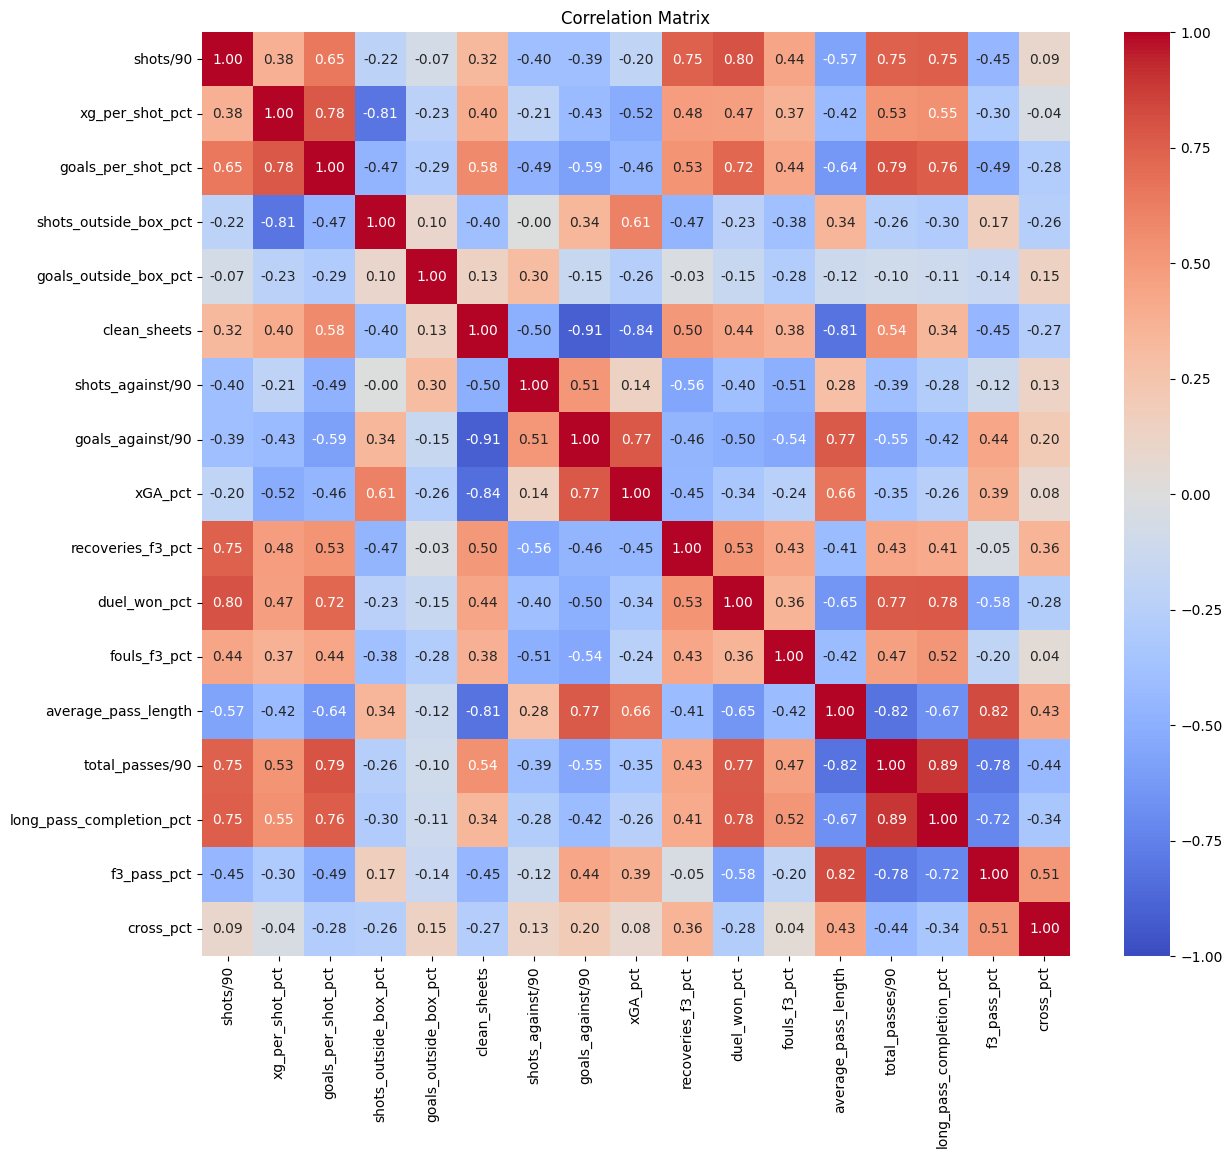

In [ ]:
correlation_matrix = dfModel.drop('team', axis=1).corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

### Data Preprocessing: Feature Scaling

Before applying the clustering models, all features are standardized using `StandardScaler` to ensure equal contribution across variables.

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(dfModel.drop('team', axis=1))

## K-Means clustering: cluster selection  

The Elbow Method is then used to analyze the relationship between the number of clusters and within-cluster inertia in order to identify a suitable value of *k*.

Based on the elbow curve, **k = 4** clusters is selected and the K-Means algorithm is fitted to the scaled data.  
Each team is then assigned to a cluster, which will be analyzed and interpreted in the following steps.


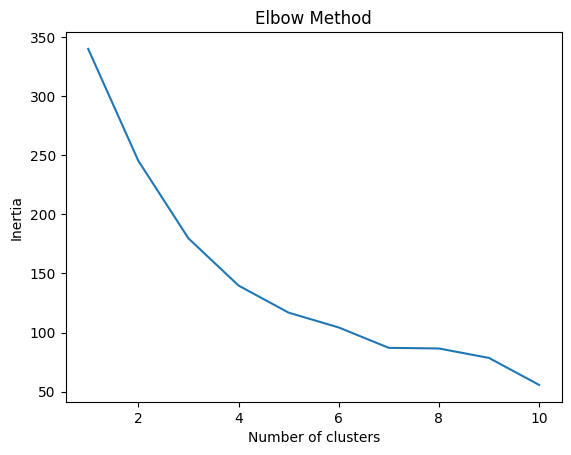

In [ ]:
inertia = []

for i in range(1, 11):
    # Fit KMeans with i clusters on the scaled data
    kmeans = KMeans(n_clusters=i, random_state=80).fit(df_scaled)
    # Store the inertia (within-cluster sum of squares)
    inertia.append(kmeans.inertia_)

# Plot inertia values to visualize the Elbow Method
plt.plot(range(1, 11), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# Initialize KMeans with the selected number of clusters
kmeans = KMeans(n_clusters=4, random_state=80)

# Fit the model on the scaled data
kmeans.fit(df_scaled)

# Assign each observation to a cluster
dfModel['cluster_KMeans'] = kmeans.predict(df_scaled)

In [ ]:
dfModel.cluster_KMeans.value_counts()

,count
cluster_KMeans,
3,8
0,5
1,5
2,2


In [ ]:
# Group teams by their assigned KMeans cluster
clusters_KMeans = dfModel.groupby('cluster_KMeans')['team'].apply(list)

# Print the teams belonging to each cluster
for cluster_label, teams in clusters_KMeans.items():
    print(f'cluster {cluster_label}: {", ".join(teams)}')

cluster 0: Athletic Club, Atlético Madrid, Málaga, Real Sociedad, Sevilla
cluster 1: Celta Vigo, Las Palmas, Real Betis, Valencia, Villarreal
cluster 2: Barcelona, Real Madrid
cluster 3: Eibar, Espanyol, Getafe, Granada, Levante UD, RC Deportivo La Coruña, Rayo Vallecano, Sporting Gijón


### K-Means cluster profiling by phase of play

Cluster-level summaries are computed by averaging the features of teams within each K-Means cluster.  
To facilitate interpretation, cluster characteristics are analyzed separately for **attack**, **build-up**, and **defense**.



In [ ]:
# Compute mean feature values per KMeans cluster
cluster_summary_KMeans = dfModel.groupby('cluster_KMeans').mean(numeric_only=True)

# Extract attack-related cluster summaries
cluster_summary_attack_KMeans = cluster_summary_KMeans[
['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct',
     'shots_outside_box_pct', 'goals_outside_box_pct']
]

# Extract build-up related cluster summaries
cluster_summary_build_KMeans = cluster_summary_KMeans[
    ['average_pass_length', 'total_passes/90',
     'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct']
]

# Extract defense-related cluster summaries
cluster_summary_defense_KMeans = cluster_summary_KMeans[
    ['clean_sheets', 'shots_against/90', 'goals_against/90',
     'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct']
]

cluster_summary_KMeans

,shots/90,xg_per_shot_pct,goals_per_shot_pct,shots_outside_box_pct,goals_outside_box_pct,clean_sheets,shots_against/90,goals_against/90,xGA_pct,recoveries_f3_pct,duel_won_pct,fouls_f3_pct,average_pass_length,total_passes/90,long_pass_completion_pct,f3_pass_pct,cross_pct
cluster_KMeans,,,,,,,,,,,,,,,,,
0,12.326316,10.807754,10.648764,35.647632,11.567873,14.6,11.221053,1.031579,9.438216,24.436951,29.291001,28.221201,19.810943,475.952632,53.365149,12.534120,3.100666
1,10.689474,10.372293,10.470134,41.101946,12.835646,11.4,12.968421,1.300000,10.544409,19.658660,29.019268,23.393627,19.777104,493.621053,55.202550,10.865622,2.050143
2,17.381579,13.203242,16.554560,33.467723,9.688243,16.0,10.631579,0.828947,9.479086,26.475157,40.415989,29.325956,18.157225,644.552632,71.059674,9.680374,2.353905
3,11.427632,9.928437,9.651309,41.182862,10.843230,6.5,12.381579,1.766447,11.795670,21.814443,28.124019,22.542703,21.134418,434.483553,51.640581,13.355132,2.851416


### PCA projection for cluster visualization

Principal Component Analysis (PCA) is applied to project the standardized feature space into two dimensions.  
This allows the K-Means clusters to be visualized in a compact and interpretable way while preserving as much variance as possible.

To improve readability, teams are annotated using short abbreviations.  
The axis labels also report the explained variance of each principal component, providing context on how much information is retained in the 2D projection.


In [ ]:
# Dictionary to map full team names to abbreviations
abbr = {
    "Real Madrid": "RMA",
    "Barcelona": "FCB",
    "Atlético Madrid": "ATM",
    "Athletic Club": "ATH",
    "Real Sociedad": "RSO",
    "Valencia": "VAL",
    "Villarreal": "VIL",
    "Real Betis": "BET",
    "Sevilla": "SEV",
    "Getafe": "GET",
    "Espanyol": "ESP",
    "Rayo Vallecano": "RAY",
    "Celta Vigo": "CEL",
    "Las Palmas": "LPA",
    "Málaga": "MLG",
    "Eibar": "EIB",
    "Granada": "GRA",
    "Levante UD": "LEV",
    "Sporting Gijón": "SPG",
    "RC Deportivo La Coruña": "DEP",
}

# Map team names to their abbreviations
team_names = dfModel['team'].tolist()
team_labels = [abbr.get(t, t) for t in team_names]

# Apply PCA to reduce data to two components
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Percentage of variance explained by each principal component
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

In [ ]:
def plot_pca_clusters(df_pca, clusters, team_labels, pc1_var, pc2_var, title):
    plt.figure(figsize=(11, 7))

    # Scatter plot of the first two principal components
    scatter = plt.scatter(
        df_pca[:, 0],
        df_pca[:, 1],
        c=clusters,
        s=140,
        alpha=0.85,
        cmap="viridis"
    )

    # Annotate each point with the team label
    for i, name in enumerate(team_labels):
        plt.annotate(
            name,
            (df_pca[i, 0], df_pca[i, 1]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.9
        )

    # Axis labels and title
    plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
    plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
    plt.title(title)

    # Legend for cluster colors
    handles, labels = scatter.legend_elements()
    plt.legend(handles, labels, title="Cluster")

    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

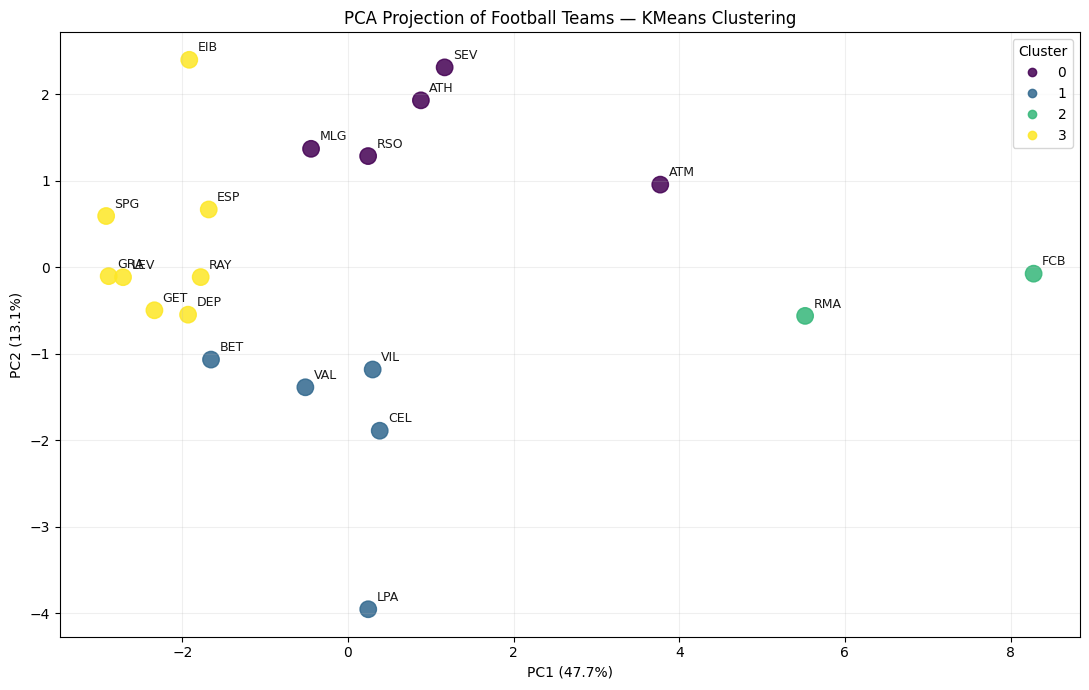

In [ ]:
plot_pca_clusters(df_pca, dfModel['cluster_KMeans'], team_labels, pc1_var, pc2_var, "PCA Projection of Football Teams — KMeans Clustering")

### Analysis of Variables Influencing Cluster Formation
This section analyzes the variables that most influence cluster formation in the K-Means model.
Feature relevance is assessed by examining the standard deviation of the cluster centroids, identifying the variables that best differentiate the clusters.

In [ ]:
# Create a DataFrame with the KMeans cluster centroids
centroids_KMeans = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=dfModel.drop(['team', 'cluster_KMeans'], axis=1).columns
)

centroids_KMeans

,shots/90,xg_per_shot_pct,goals_per_shot_pct,shots_outside_box_pct,goals_outside_box_pct,clean_sheets,shots_against/90,goals_against/90,xGA_pct,recoveries_f3_pct,duel_won_pct,fouls_f3_pct,average_pass_length,total_passes/90,long_pass_completion_pct,f3_pass_pct,cross_pct
0,0.128042,0.143102,-0.061464,-0.612115,0.052654,0.813029,-0.577779,-0.840612,-0.816528,0.829625,-0.141455,0.951521,-0.329070,-0.068281,-0.244407,0.242459,0.802016
1,-0.668378,-0.138812,-0.136183,0.381631,0.467585,0.145928,0.621113,-0.178508,-0.078358,-1.113838,-0.207982,-0.412430,-0.360388,0.188979,0.047393,-0.838933,-1.125956
2,2.587723,1.693922,2.408876,-1.009283,-0.562534,1.104886,-0.982225,-1.340436,-0.789255,1.658619,2.582249,1.263651,-1.859589,2.386611,2.565689,-1.607120,-0.568476
3,-0.309221,-0.426161,-0.478690,0.396373,-0.184516,-0.875570,0.218473,0.972059,0.756617,-0.237021,-0.427164,-0.652845,0.895808,-0.672089,-0.518289,0.774576,0.344581


In [ ]:
# Compute and sort the standard deviation of features across KMeans centroids
centroids_KMeans_std = centroids_KMeans.std().sort_values(ascending=False)

centroids_KMeans_std

,0
shots/90,1.471931
duel_won_pct,1.425792
long_pass_completion_pct,1.420960
total_passes/90,1.334914
goals_per_shot_pct,1.329627
recoveries_f3_pct,1.212806
average_pass_length,1.127743
f3_pass_pct,1.070027
goals_against/90,0.999812
fouls_f3_pct,0.960546


In [ ]:
attack_vars = ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct', 'shots_outside_box_pct', 'goals_outside_box_pct']
build_up_vars = ['average_pass_length', 'total_passes/90', 'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct']
defense_vars = ['clean_sheets', 'shots_against/90', 'goals_against/90', 'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct']

In [ ]:
# Compute average importance per feature group based on centroid variability
group_importance_KMeans_std = {
    'Attack': centroids_KMeans_std[attack_vars].mean(),
    'Build-up': centroids_KMeans_std[build_up_vars].mean(),
    'Defense': centroids_KMeans_std[defense_vars].mean()
}

# Sort groups by importance
group_importance_KMeans_std = pd.Series(group_importance_KMeans_std).sort_values(ascending=False)

group_importance_KMeans_std

,0
Build-up,1.165003
Defense,0.992985
Attack,0.978178


### Attacking profile visualization by K-Means cluster

This function plot_attack_cluster_summary() visualizes the attacking characteristics of each K-Means cluster using bar charts.  
Clusters are compared across key offensive dimensions, including shot volume, shot quality, and shooting efficiency by location.

These plots support the tactical interpretation of the clusters by highlighting distinct attacking profiles.


In [ ]:
def plot_attack_cluster_summary(cluster_summary):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    # Shot volume per cluster
    cluster_summary[['shots/90']].plot(
        kind='bar',
        ax=axes[0],
        legend=True
    )
    axes[0].set_title('Volume')
    axes[0].set_ylabel('Mean')
    axes[0].set_xlabel('Cluster')

    # Shot quality per cluster
    cluster_summary[['xg_per_shot_pct']].plot(
        kind='bar',
        ax=axes[1],
        legend=True
    )
    axes[1].set_title('Shot Quality')
    axes[1].set_xlabel('Cluster')

    # Shot location and conversion metrics
    cluster_summary[
        ['shots_outside_box_pct', 'goals_outside_box_pct', 'goals_per_shot_pct']
    ].plot(
        kind='bar',
        ax=axes[2],
        legend=True
    )
    axes[2].set_title('Shot Location & Conversion')
    axes[2].set_xlabel('Cluster')

    # Formatting
    for ax in axes:
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

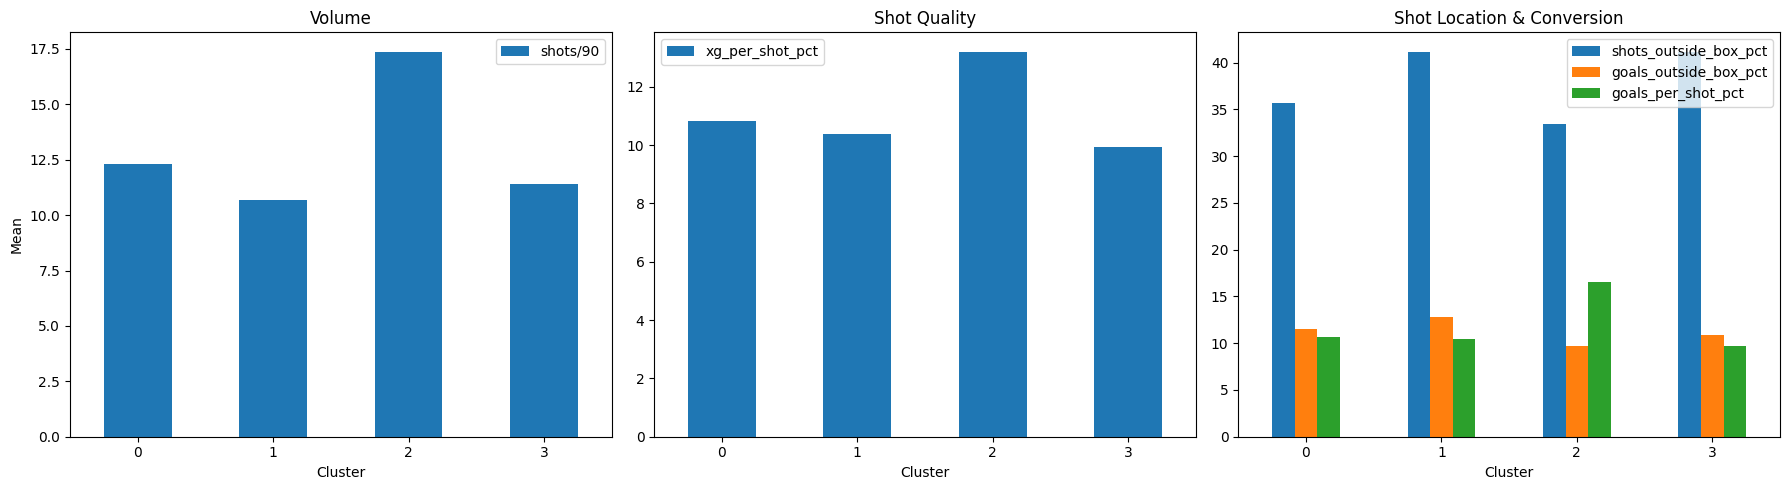

In [ ]:
plot_attack_cluster_summary(cluster_summary_attack_KMeans)

### Build-up profile visualization by K-Means cluster

This function plot_build_cluster_summary() visualizes the build-up characteristics of each K-Means cluster using bar charts.  
Clusters are compared in terms of passing style, construction volume, and build-up intent and efficiency.

These plots help distinguish possession-oriented teams from more direct or cross-focused build-up styles within the clustering results.


In [ ]:
def plot_build_cluster_summary(cluster_summary):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    # Passing style per cluster
    cluster_summary[['average_pass_length']].plot(
        kind='bar',
        ax=axes[0],
        legend=True
    )
    axes[0].set_title('Passing Style')
    axes[0].set_ylabel('Mean')
    axes[0].set_xlabel('Cluster')

    # Build-up volume per cluster
    cluster_summary[['total_passes/90']].plot(
        kind='bar',
        ax=axes[1],
        legend=True
    )
    axes[1].set_title('Build Volume')
    axes[1].set_xlabel('Cluster')

    # Build-up intent and efficiency
    cluster_summary[
        ['long_pass_completion_pct', 'f3_pass_pct', 'cross_pct']
    ].plot(
        kind='bar',
        ax=axes[2],
        legend=True
    )
    axes[2].set_title('Build Intent & Efficiency')
    axes[2].set_xlabel('Cluster')

    # Formatting
    for ax in axes:
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

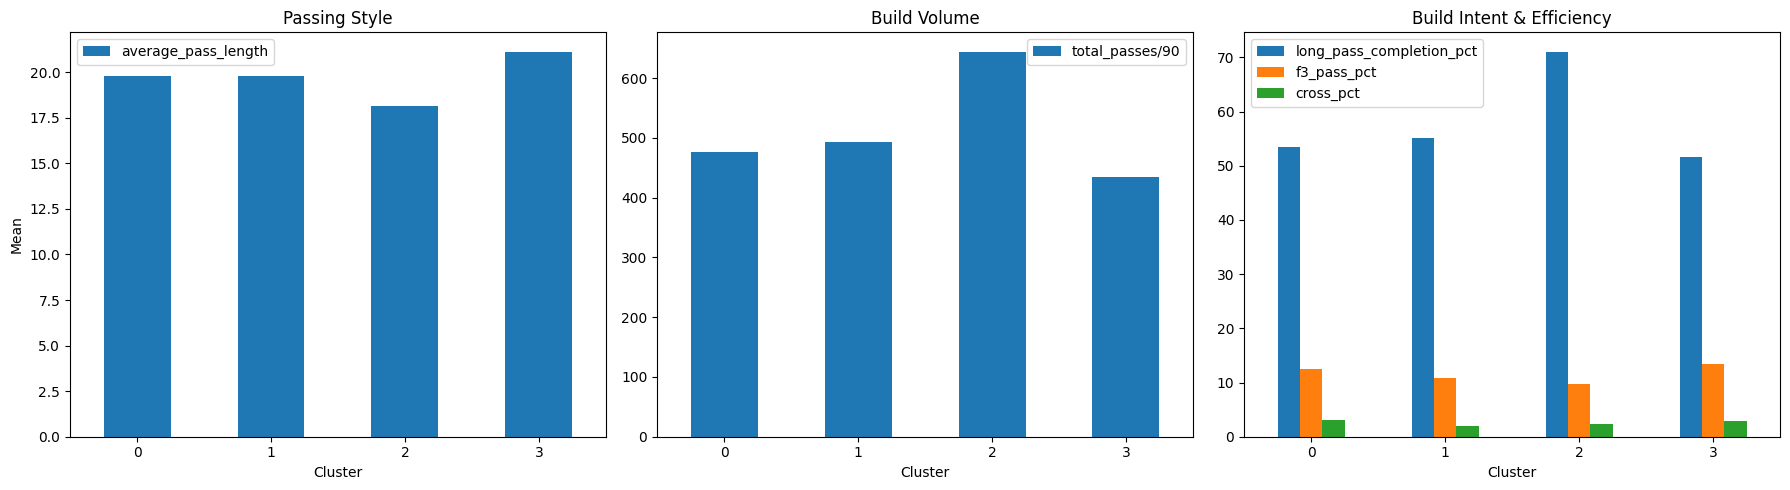

In [ ]:
plot_build_cluster_summary(cluster_summary_build_KMeans)

### Defensive profile visualization by K-Means cluster

This function plot_defense_cluster_summary() visualizes the defensive characteristics of each K-Means cluster using bar charts.  
Clusters are compared across defensive intensity, efficiency, and exposure metrics, including recoveries, duel success, fouls, shots conceded, and clean sheets.

These visualizations support a structured interpretation of defensive styles within the K-Means clustering results.


In [ ]:
def plot_defense_cluster_summary(cluster_summary):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    # Defensive action and efficiency percentages
    cluster_summary[
        ['recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct', 'xGA_pct']
    ].plot(
        kind='bar',
        ax=axes[0],
        legend=True
    )
    axes[0].set_title('Defensive Percentages')
    axes[0].set_ylabel('Mean')
    axes[0].set_xlabel('Cluster')

    # Clean sheets per cluster
    cluster_summary[
        ['clean_sheets']
    ].plot(
        kind='bar',
        ax=axes[1],
        legend=True
    )
    axes[1].set_title('Clean Sheets')
    axes[1].set_xlabel('Cluster')

    # Defensive exposure metrics
    cluster_summary[
        ['goals_against/90', 'shots_against/90']
    ].plot(
        kind='bar',
        ax=axes[2],
        legend=True
    )
    axes[2].set_title('Defensive Exposure (/90)')
    axes[2].set_xlabel('Cluster')

    # Formatting
    for ax in axes:
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

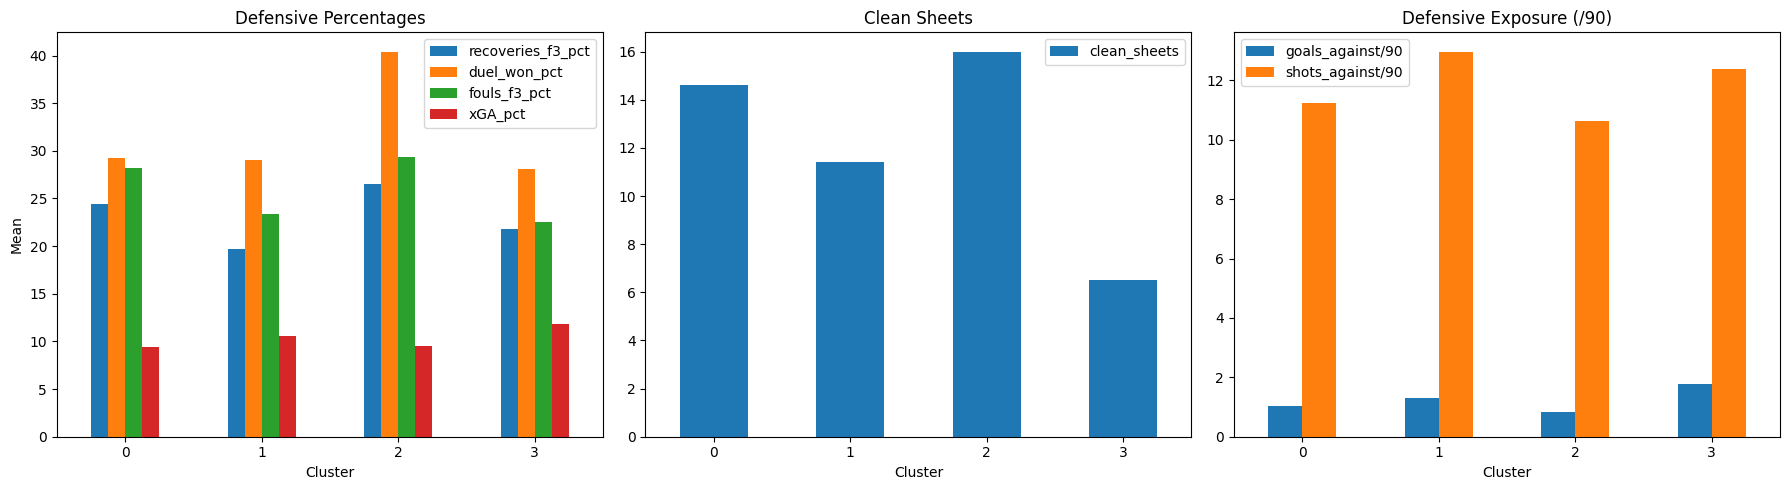

In [ ]:
plot_defense_cluster_summary(cluster_summary_defense_KMeans)

### Pairwise feature visualization by K-Means cluster

Pair plots are used to visualize the distribution and separation of teams across key attacking, build-up, and defensive features.  
Coloring observations by their K-Means cluster assignment helps assess cluster compactness, overlap, and interpretability in the original feature space.


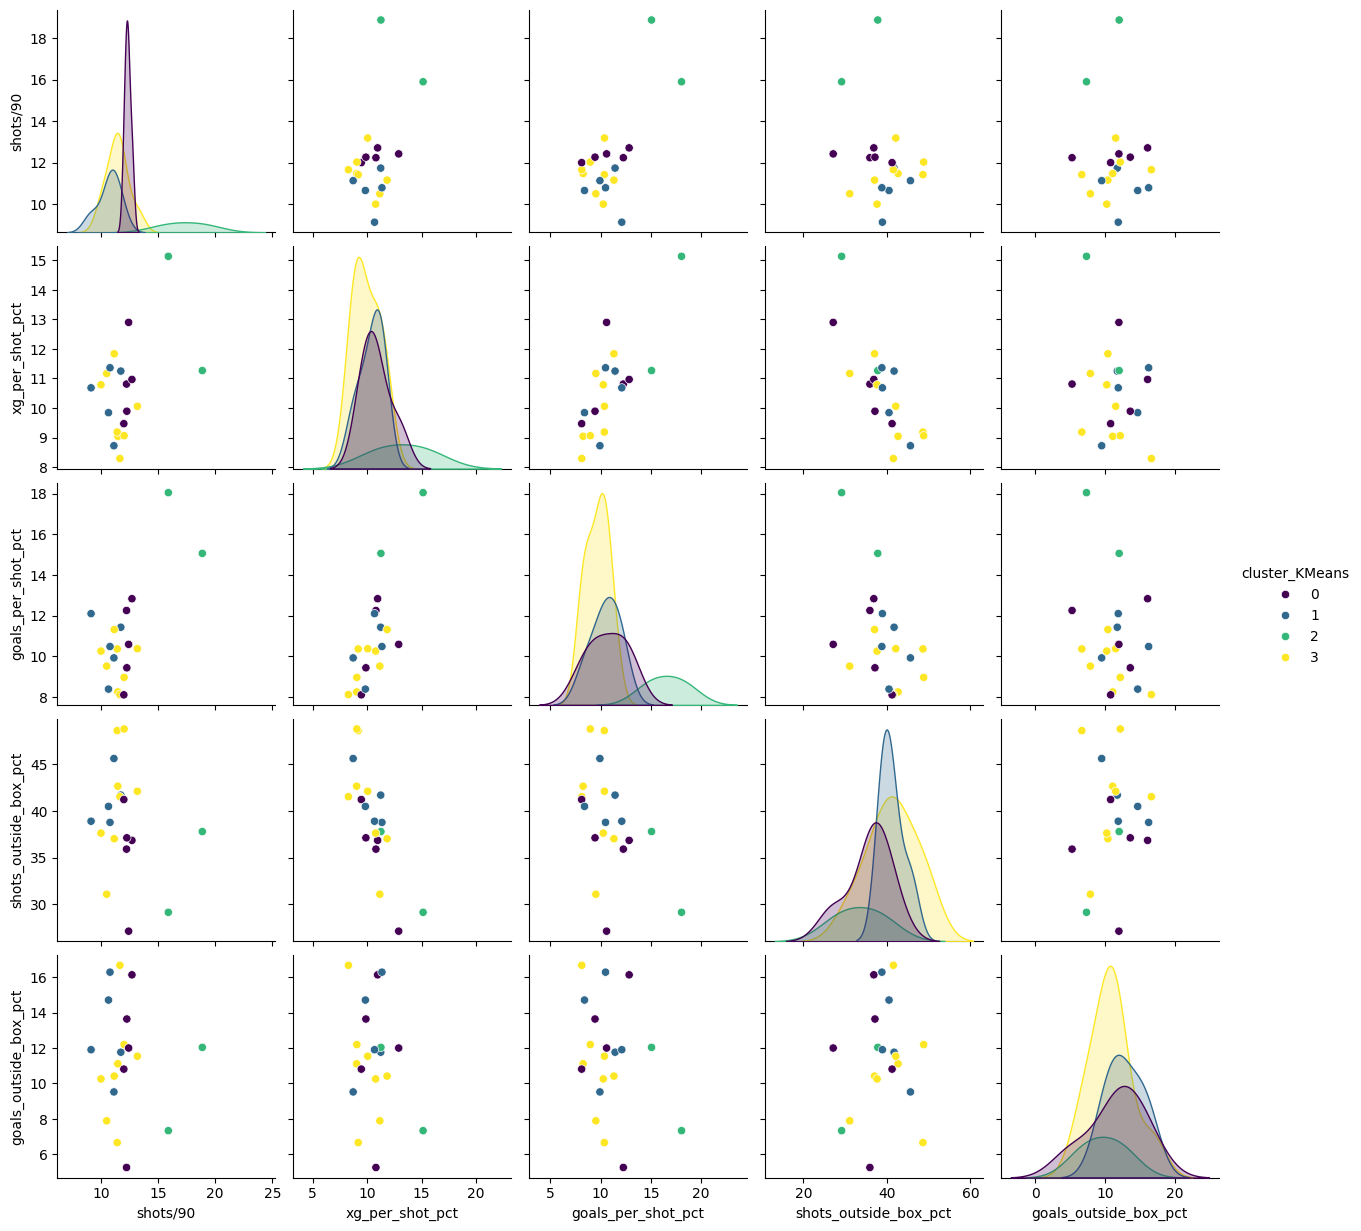

In [ ]:
selected_features_attack = ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct', 'shots_outside_box_pct', 'goals_outside_box_pct', 'cluster_KMeans']
sns.pairplot(dfModel[selected_features_attack], hue='cluster_KMeans', palette='viridis')

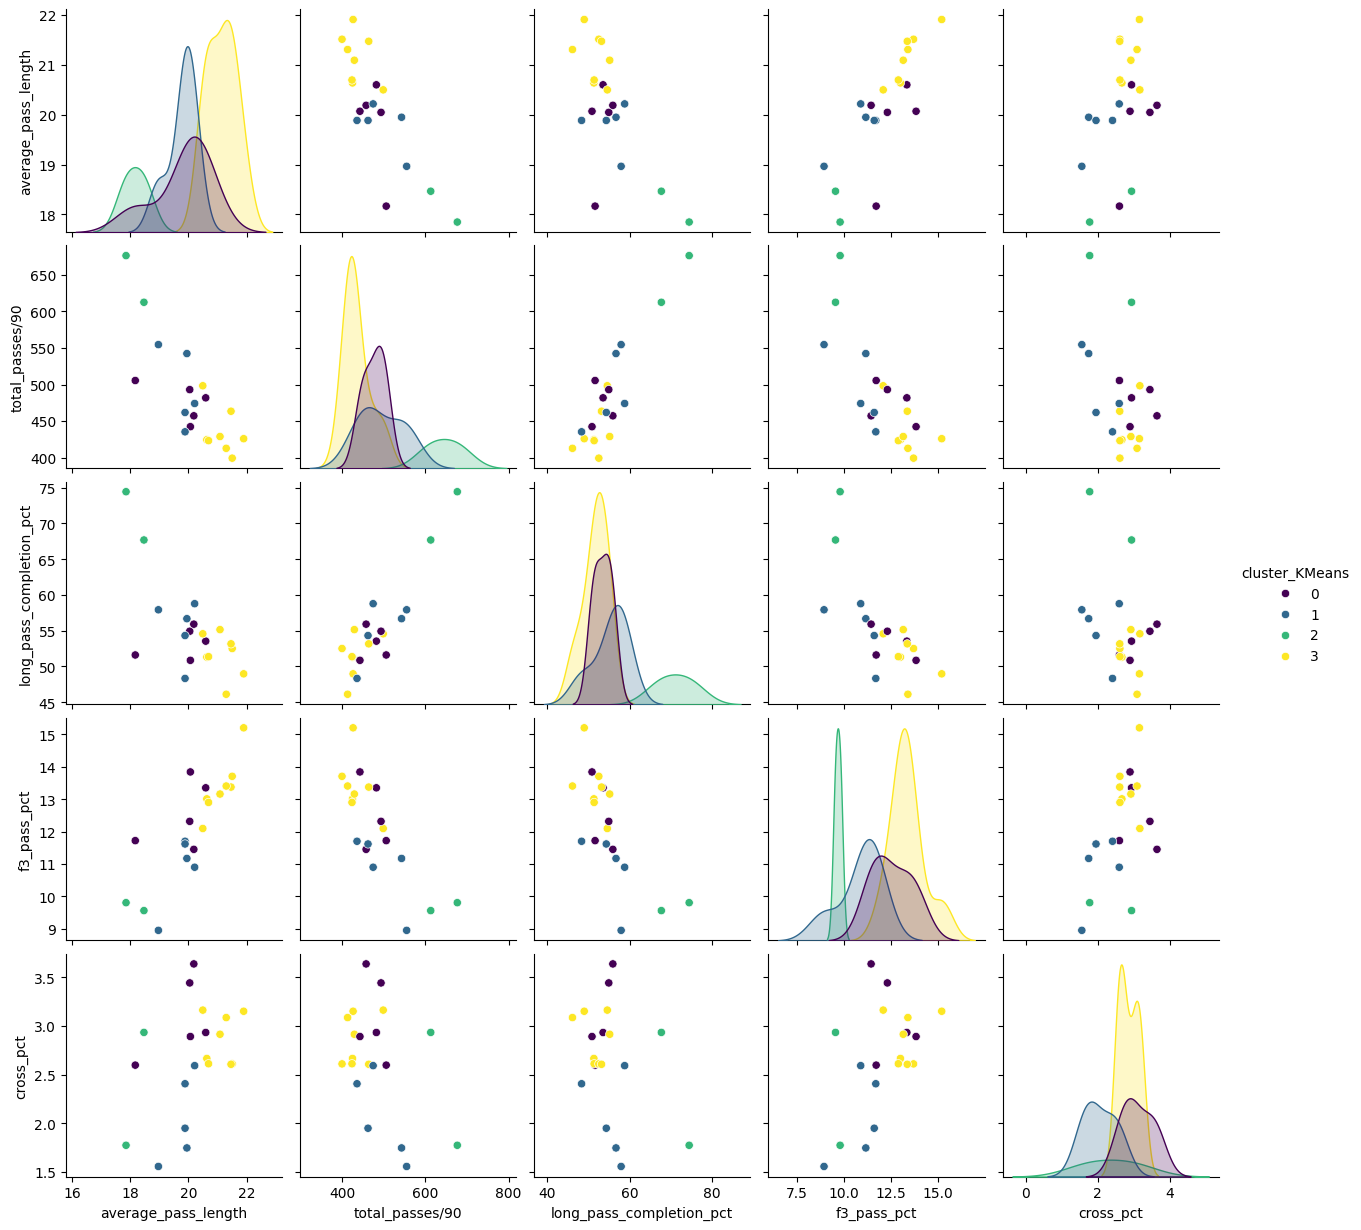

In [ ]:
selected_features_build = ['average_pass_length', 'total_passes/90', 'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct', 'cluster_KMeans']
sns.pairplot(dfModel[selected_features_build], hue='cluster_KMeans', palette='viridis')

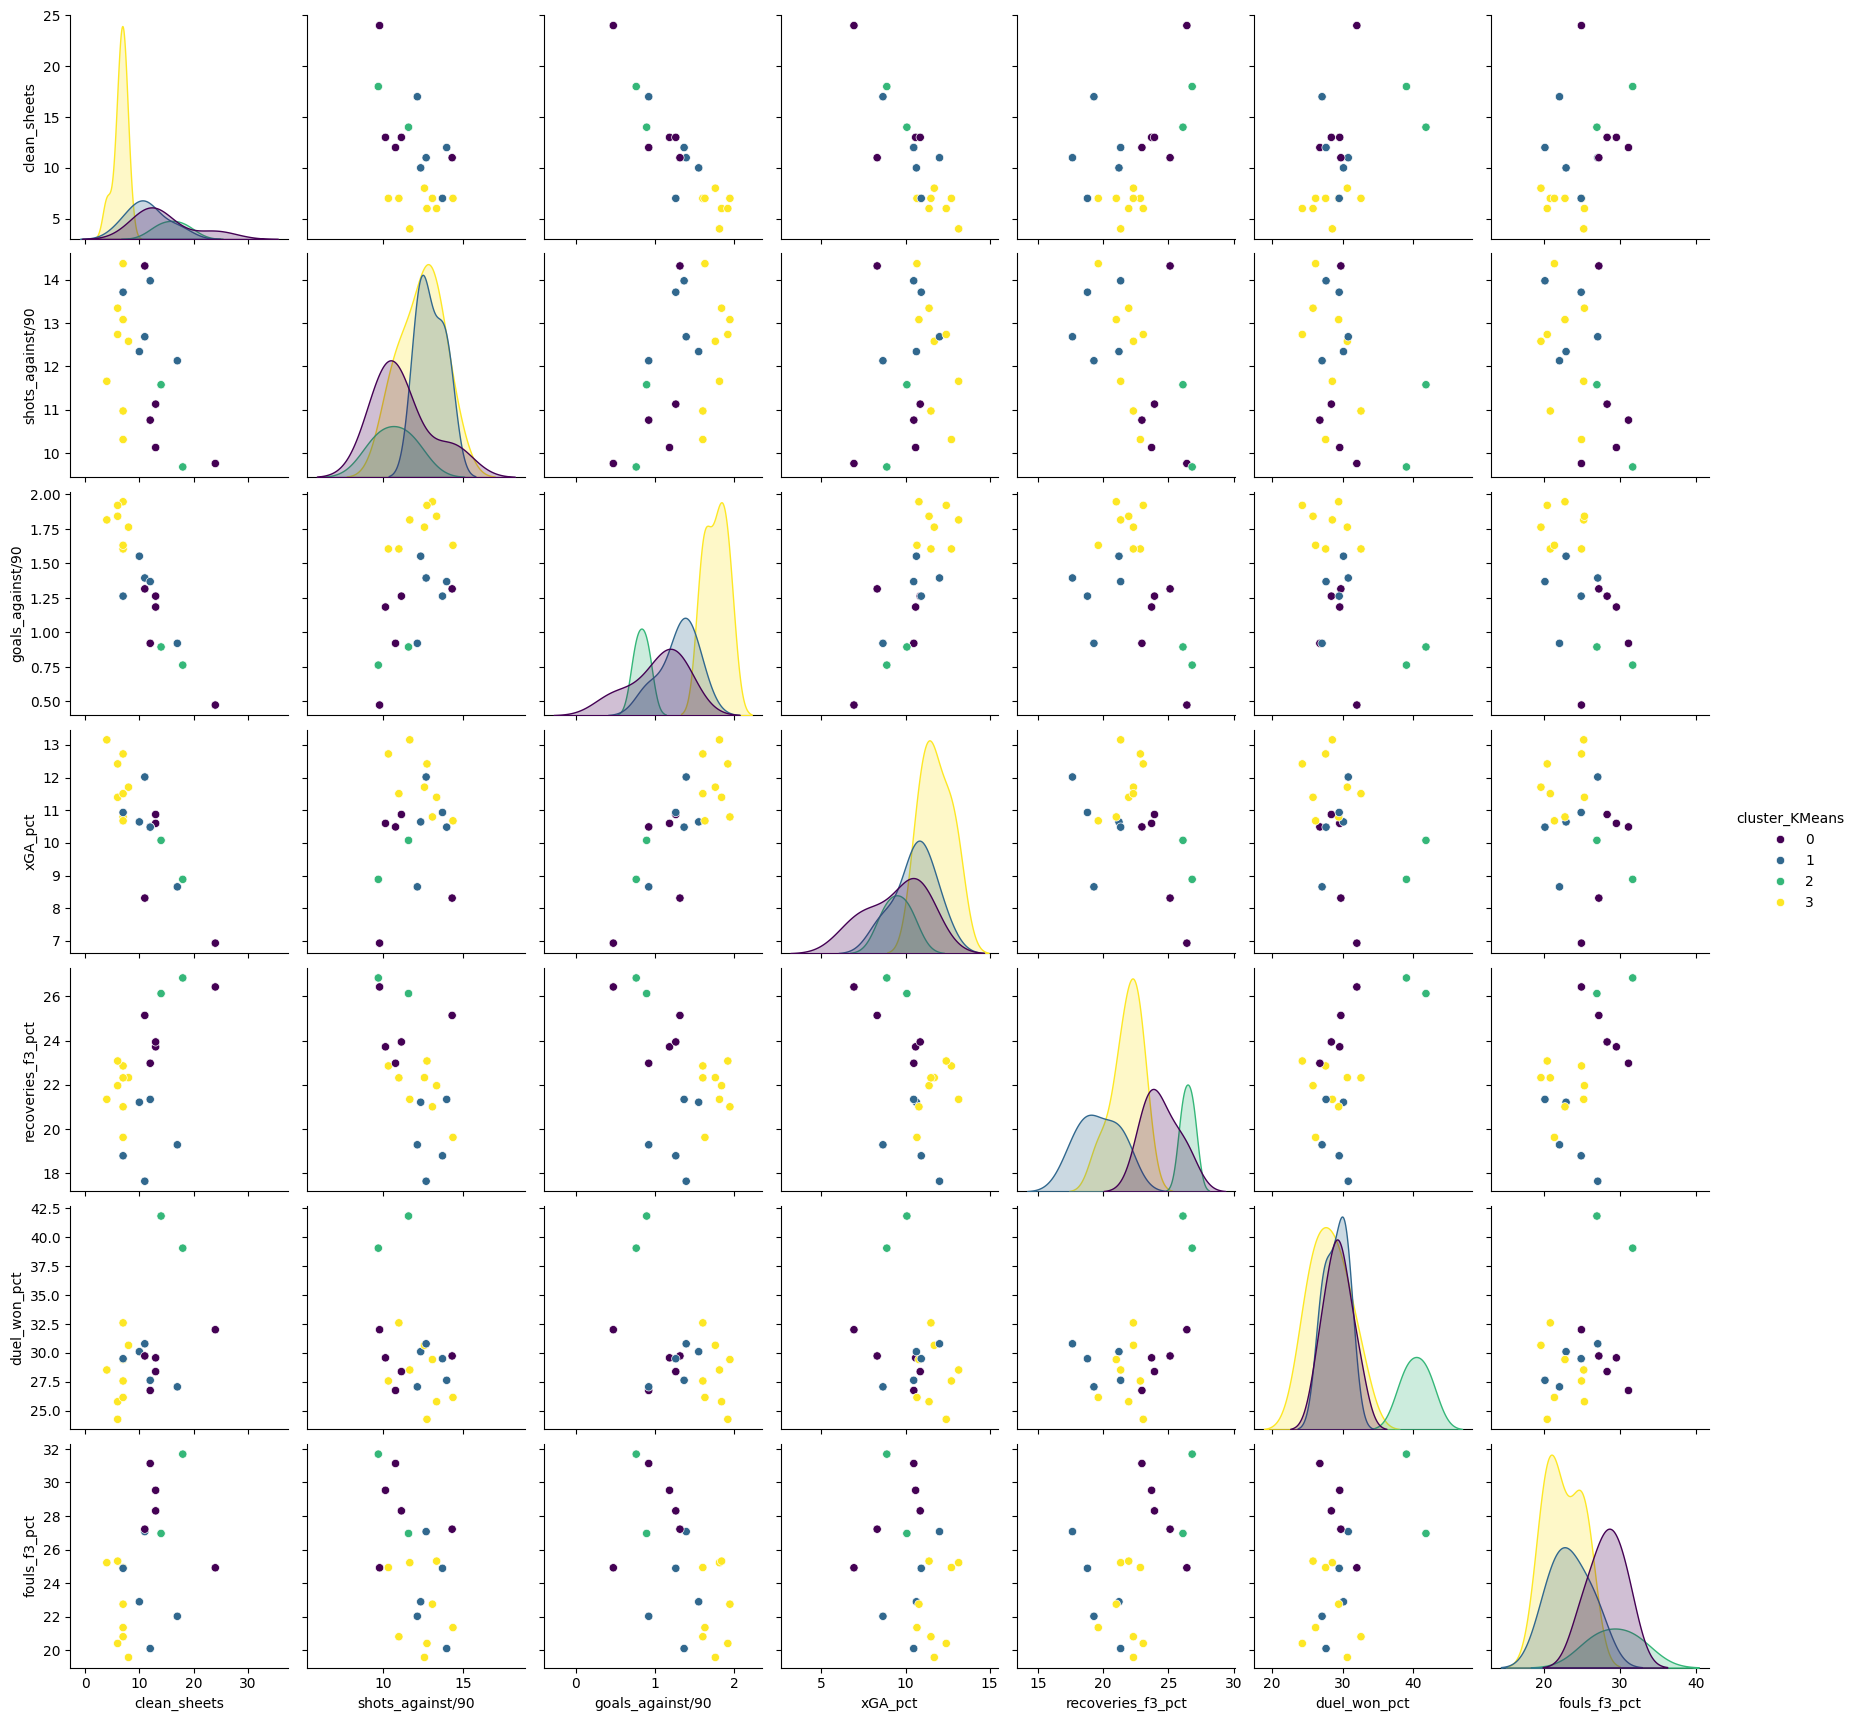

In [ ]:
selected_features_defense = ['clean_sheets', 'shots_against/90', 'goals_against/90', 'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct', 'cluster_KMeans']
sns.pairplot(dfModel[selected_features_defense], hue='cluster_KMeans', palette='viridis')

## Gaussian Mixture Model: cluster selection and fitting

BIC and AIC criteria are used to guide the selection of the number of components in the Gaussian Mixture Model.  
Based on these scores, **four clusters** are selected, and a GMM with a **full covariance structure** is fitted to the standardized feature space in order to capture correlations between football performance metrics.


In [ ]:
# Evaluate BIC and AIC across different GMM configurations
n_components_range = range(1, 11)

bic = []
aic = []

# Fit GMMs with varying numbers of components and store information criteria
for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(df_scaled)
    bic.append(gmm.bic(df_scaled))
    aic.append(gmm.aic(df_scaled))

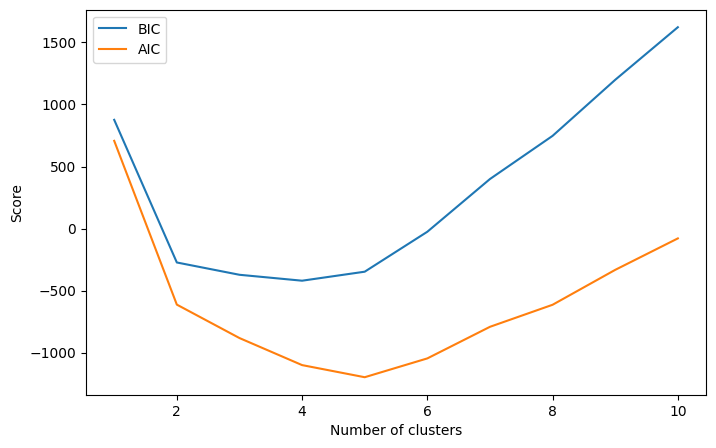

In [ ]:
# Plot BIC and AIC scores to select the optimal number of GMM components
plt.figure(figsize=(8,5))
plt.plot(n_components_range, bic, label='BIC')
plt.plot(n_components_range, aic, label='AIC')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [ ]:
# Fit the final GMM with the selected number of components
gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42
)

# Assign each team to a GMM cluster
clusters_GMM = gmm.fit_predict(df_scaled)

dfModel['cluster_GMM'] = clusters_GMM

In [ ]:
dfModel.cluster_GMM.value_counts()

,count
cluster_GMM,
3,9
0,5
1,4
2,2


In [ ]:
# Group teams by their assigned GMM cluster
clusters_GMM = dfModel.groupby('cluster_GMM')['team'].apply(list)

# Print the teams belonging to each cluster
for cluster_label, teams in clusters_GMM.items():
    print(f'cluster {cluster_label}: {", ".join(teams)}')

cluster 0: Athletic Club, Eibar, Granada, Málaga, RC Deportivo La Coruña
cluster 1: Atlético Madrid, Celta Vigo, Las Palmas, Villarreal
cluster 2: Barcelona, Real Madrid
cluster 3: Espanyol, Getafe, Levante UD, Rayo Vallecano, Real Betis, Real Sociedad, Sevilla, Sporting Gijón, Valencia


### GMM cluster profiling

Cluster-level summaries are computed by averaging feature values within each GMM cluster.  


In [ ]:
# Compute mean feature values per GMM cluster
cluster_summary_GMM = dfModel.groupby('cluster_GMM').mean(numeric_only=True)

# Extract attack-related cluster summaries
cluster_summary_attack_GMM = cluster_summary_GMM[
    ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct',
     'shots_outside_box_pct', 'goals_outside_box_pct']
]

# Extract build-up related cluster summaries
cluster_summary_build_GMM = cluster_summary_GMM[
    ['average_pass_length', 'total_passes/90',
     'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct']
]

# Extract defense-related cluster summaries
cluster_summary_defense_GMM = cluster_summary_GMM[
    ['clean_sheets', 'shots_against/90', 'goals_against/90',
     'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct']
]

cluster_summary_GMM

,shots/90,xg_per_shot_pct,goals_per_shot_pct,shots_outside_box_pct,goals_outside_box_pct,clean_sheets,shots_against/90,goals_against/90,xGA_pct,recoveries_f3_pct,duel_won_pct,fouls_f3_pct,average_pass_length,total_passes/90,long_pass_completion_pct,f3_pass_pct,cross_pct,cluster_KMeans
cluster_GMM,,,,,,,,,,,,,,,,,,
0,11.768421,10.073013,10.206614,42.316872,9.070485,8.600000,10.768421,1.426316,11.693086,22.641459,29.005588,26.324570,21.106466,442.515789,51.803694,13.893582,2.838637,1.800000
1,11.177632,10.405873,11.576060,40.772104,12.330577,15.500000,11.730263,1.085526,9.560091,21.143749,29.990670,24.224882,19.239573,516.072368,55.129423,10.862646,1.962435,0.750000
2,17.381579,13.203242,16.554560,33.467723,9.688243,16.000000,10.631579,0.828947,9.479086,26.475157,40.415989,29.325956,18.157225,644.552632,71.059674,9.680374,2.353905,2.000000
3,11.438596,10.371019,9.496405,37.615334,12.676522,8.555556,13.248538,1.590643,10.841410,21.912368,27.950320,23.321487,20.502773,449.652047,52.936332,12.324587,2.946939,1.888889


### PCA visualization of GMM clusters

The GMM clustering results are projected onto a 2D PCA space to visually assess cluster separation and structure.

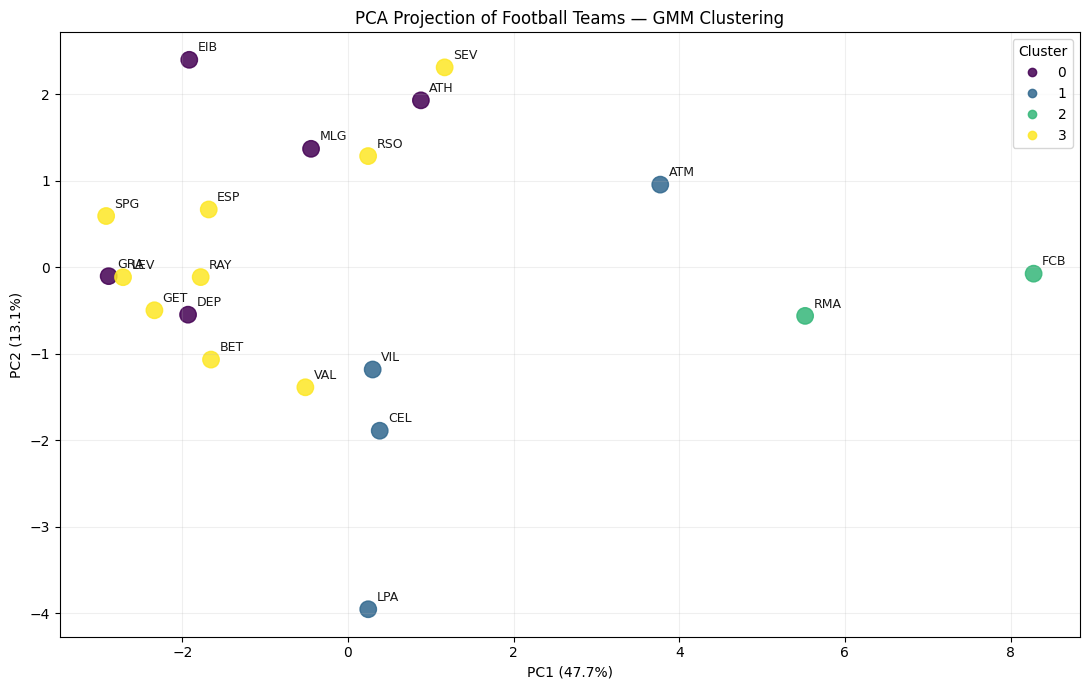

In [ ]:
plot_pca_clusters(df_pca, dfModel['cluster_GMM'], team_labels, pc1_var, pc2_var, "PCA Projection of Football Teams — GMM Clustering")

### Analysis of Variables Influencing Cluster Formation
In this subsection, feature relevance in the Gaussian Mixture Model is analyzed based on the statistical properties of the model components.
Specifically, the analysis focuses on the variability of component means across clusters and the average intra-cluster variance for each feature, allowing the identification of variables that contribute most to cluster differentiation while remaining internally consistent.

In [ ]:
# Create a DataFrame with the GMM component means
gmm_means = pd.DataFrame(
    gmm.means_,
    columns=dfModel.drop(['team', 'cluster_GMM', 'cluster_KMeans'], axis=1).columns
)

In [ ]:
# Compute and sort the standard deviation of features across GMM component means
mean_std_GMM = gmm_means.std().sort_values(ascending=False)

mean_std_GMM

,0
shots/90,1.445015
long_pass_completion_pct,1.427961
duel_won_pct,1.414439
total_passes/90,1.363208
goals_per_shot_pct,1.331563
average_pass_length,1.218963
f3_pass_pct,1.182215
recoveries_f3_pct,0.963250
xg_per_shot_pct,0.950108
clean_sheets,0.864303


In [ ]:
# Compute average feature importance per group based on GMM mean variability
group_importance_GMM_mean = {
    'Attack': mean_std_GMM[attack_vars].mean(),
    'Build-up': mean_std_GMM[build_up_vars].mean(),
    'Defense': mean_std_GMM[defense_vars].mean()
}

pd.Series(group_importance_GMM_mean).sort_values(ascending=False)

,0
Build-up,1.205622
Attack,1.007337
Defense,0.911182


### GMM cluster visualization

The same cluster-level visualizations used for K-Means are applied to the Gaussian Mixture Model results.  



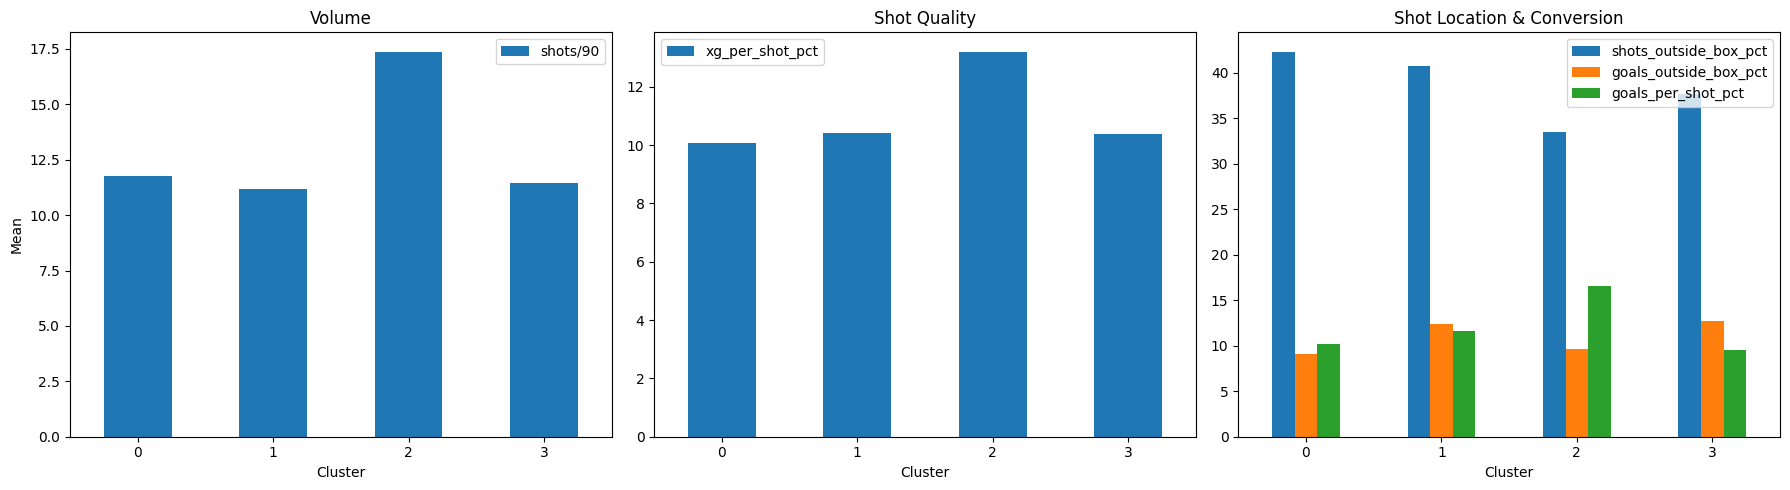

In [ ]:
plot_attack_cluster_summary(cluster_summary_attack_GMM)

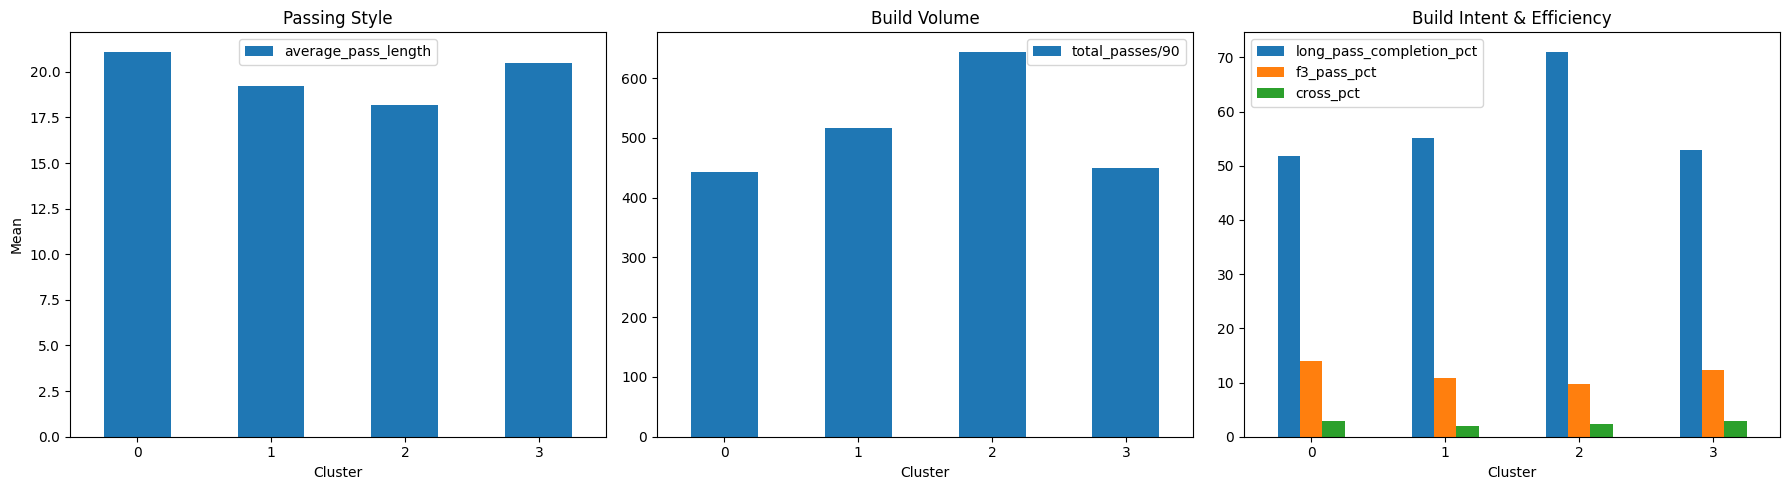

In [ ]:
plot_build_cluster_summary(cluster_summary_build_GMM)

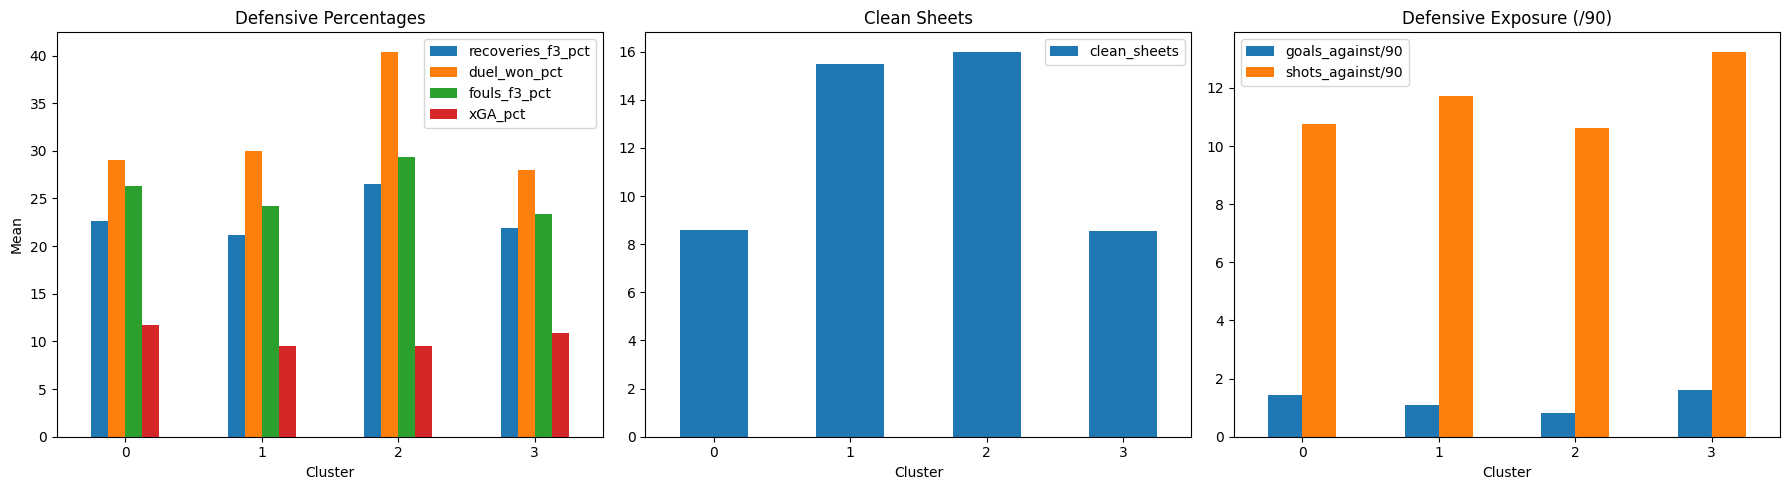

In [ ]:
plot_defense_cluster_summary(cluster_summary_defense_GMM)

### Pairwise feature inspection for GMM clusters

Pair plots are reused to inspect cluster separation and overlap in the original feature space under the GMM assignments.

In [ ]:
selected_features_attack = ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct', 'shots_outside_box_pct', 'goals_outside_box_pct', 'cluster_GMM']
sns.pairplot(dfModel[selected_features_attack], hue='cluster_GMM', palette='viridis')

In [ ]:
selected_features_build = ['average_pass_length', 'total_passes/90', 'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct', 'cluster_GMM']
sns.pairplot(dfModel[selected_features_build], hue='cluster_GMM', palette='viridis')

In [ ]:
selected_features_defense = ['clean_sheets', 'shots_against/90', 'goals_against/90', 'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct', 'cluster_GMM']
sns.pairplot(dfModel[selected_features_defense], hue='cluster_GMM', palette='viridis')

## Hierarchical clustering: cluster selection and fitting

Hierarchical clustering with Ward linkage is applied and evaluated using the silhouette score across different numbers of clusters.  
Based on this evaluation, **2 clusters** are selected and assigned to the teams for further analysis.


In [ ]:
# Perform hierarchical clustering using Ward's method
Z = linkage(df_scaled, method='ward')

# Use team names as dendrogram labels
labels = dfModel["team"].astype(str).tolist()

# Plot the hierarchical clustering dendrogram
plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Dendrogram - Hierarchical Clustering")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate silhouette score for different numbers of hierarchical clusters
scores = []

# Fit hierarchical clustering models with varying k and compute silhouette scores
for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    scores.append(score)

In [ ]:
# Plot silhouette scores to select the optimal number of hierarchical clusters
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
# Fit the final hierarchical clustering model
hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

# Assign each team to a hierarchical cluster
clusters_HC = hc.fit_predict(df_scaled)

dfModel['cluster_HC'] = clusters_HC

In [ ]:
dfModel.cluster_HC.value_counts()

In [ ]:
# Group teams by their assigned hierarchical cluster
clusters_HC = dfModel.groupby('cluster_HC')['team'].apply(list)

# Print the teams belonging to each cluster
for cluster_label, teams in clusters_HC.items():
    print(f'cluster {cluster_label}: {", ".join(teams)}')

### Hierarchical clustering: cluster profiling

Cluster-level summaries are computed for the hierarchical clustering results.


In [ ]:
# Compute mean feature values per hierarchical cluster
cluster_summary_HC = dfModel.groupby('cluster_HC').mean(numeric_only=True)

# Extract attack-related cluster summaries
cluster_summary_attack_HC = cluster_summary_HC[
    ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct',
     'shots_outside_box_pct', 'goals_outside_box_pct']
]

# Extract build-up related cluster summaries
cluster_summary_build_HC = cluster_summary_HC[
    ['average_pass_length', 'total_passes/90',
     'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct']
]

# Extract defense-related cluster summaries
cluster_summary_defense_HC = cluster_summary_HC[
    ['clean_sheets', 'shots_against/90', 'goals_against/90',
     'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct']
]

cluster_summary_HC

### PCA visualization of hierarchical clusters

Hierarchical clustering results are projected onto a 2D PCA space to assess cluster structure and separation using the same reduced representation.


In [ ]:
plot_pca_clusters(df_pca, dfModel['cluster_HC'], team_labels, pc1_var, pc2_var, "PCA Projection of Football Teams — AH Clustering")

###Analysis of Variables Influencing Cluster Formation
In the agglomerative hierarchical clustering using Ward linkage, feature relevance is assessed by comparing the mean values of each variable between the two resulting clusters.
Since Ward’s method minimizes within-cluster variance, variables showing larger differences between clusters are considered to have a stronger influence on the clustering structure.

In [ ]:
# Compute absolute mean differences between the two hierarchical clusters
mean_diff_HC = (cluster_summary_HC.iloc[0] - cluster_summary_HC.iloc[1]).abs()

# Rank features by their absolute mean difference
mean_diff_HC.sort_values(ascending=False)

In [ ]:
# Compute average group-level differences between hierarchical clusters
group_importance_hc = {
    'Attack': mean_diff_HC[attack_vars].mean(),
    'Build-up': mean_diff_HC[build_up_vars].mean(),
    'Defense': mean_diff_HC[defense_vars].mean()
}

pd.Series(group_importance_hc).sort_values(ascending=False)

### Hierarchical clustering: cluster visualization

The same cluster-level visualizations used in previous methods are applied to the hierarchical clustering results.


In [ ]:
plot_attack_cluster_summary(cluster_summary_attack_HC)

In [ ]:
plot_build_cluster_summary(cluster_summary_build_HC)

In [ ]:
plot_defense_cluster_summary(cluster_summary_defense_HC)

### Pairwise feature inspection for hierarchical clusters

Pair plots are reused to inspect cluster separation and overlap in the original feature space under hierarchical cluster assignments.


In [ ]:
selected_features_attack = ['shots/90', 'xg_per_shot_pct', 'goals_per_shot_pct', 'shots_outside_box_pct', 'goals_outside_box_pct', 'cluster_HC']
sns.pairplot(dfModel[selected_features_attack], hue='cluster_HC', palette='viridis')

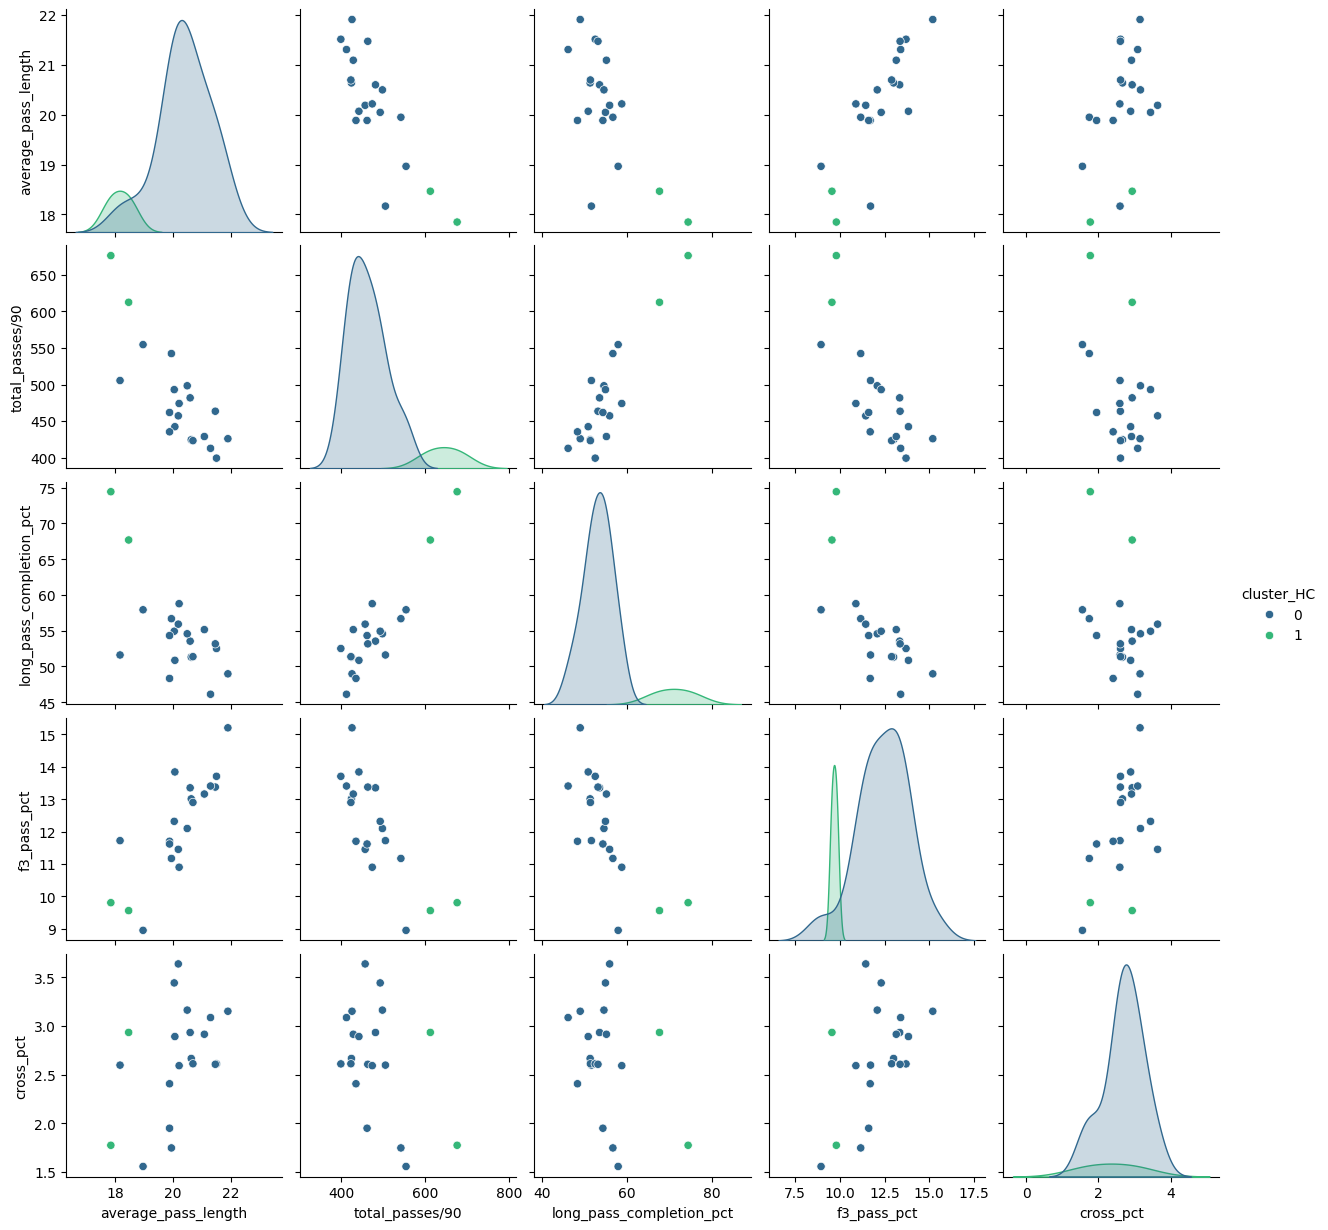

In [ ]:
selected_features_build = ['average_pass_length', 'total_passes/90', 'long_pass_completion_pct', 'f3_pass_pct', 'cross_pct', 'cluster_HC']
sns.pairplot(dfModel[selected_features_build], hue='cluster_HC', palette='viridis')

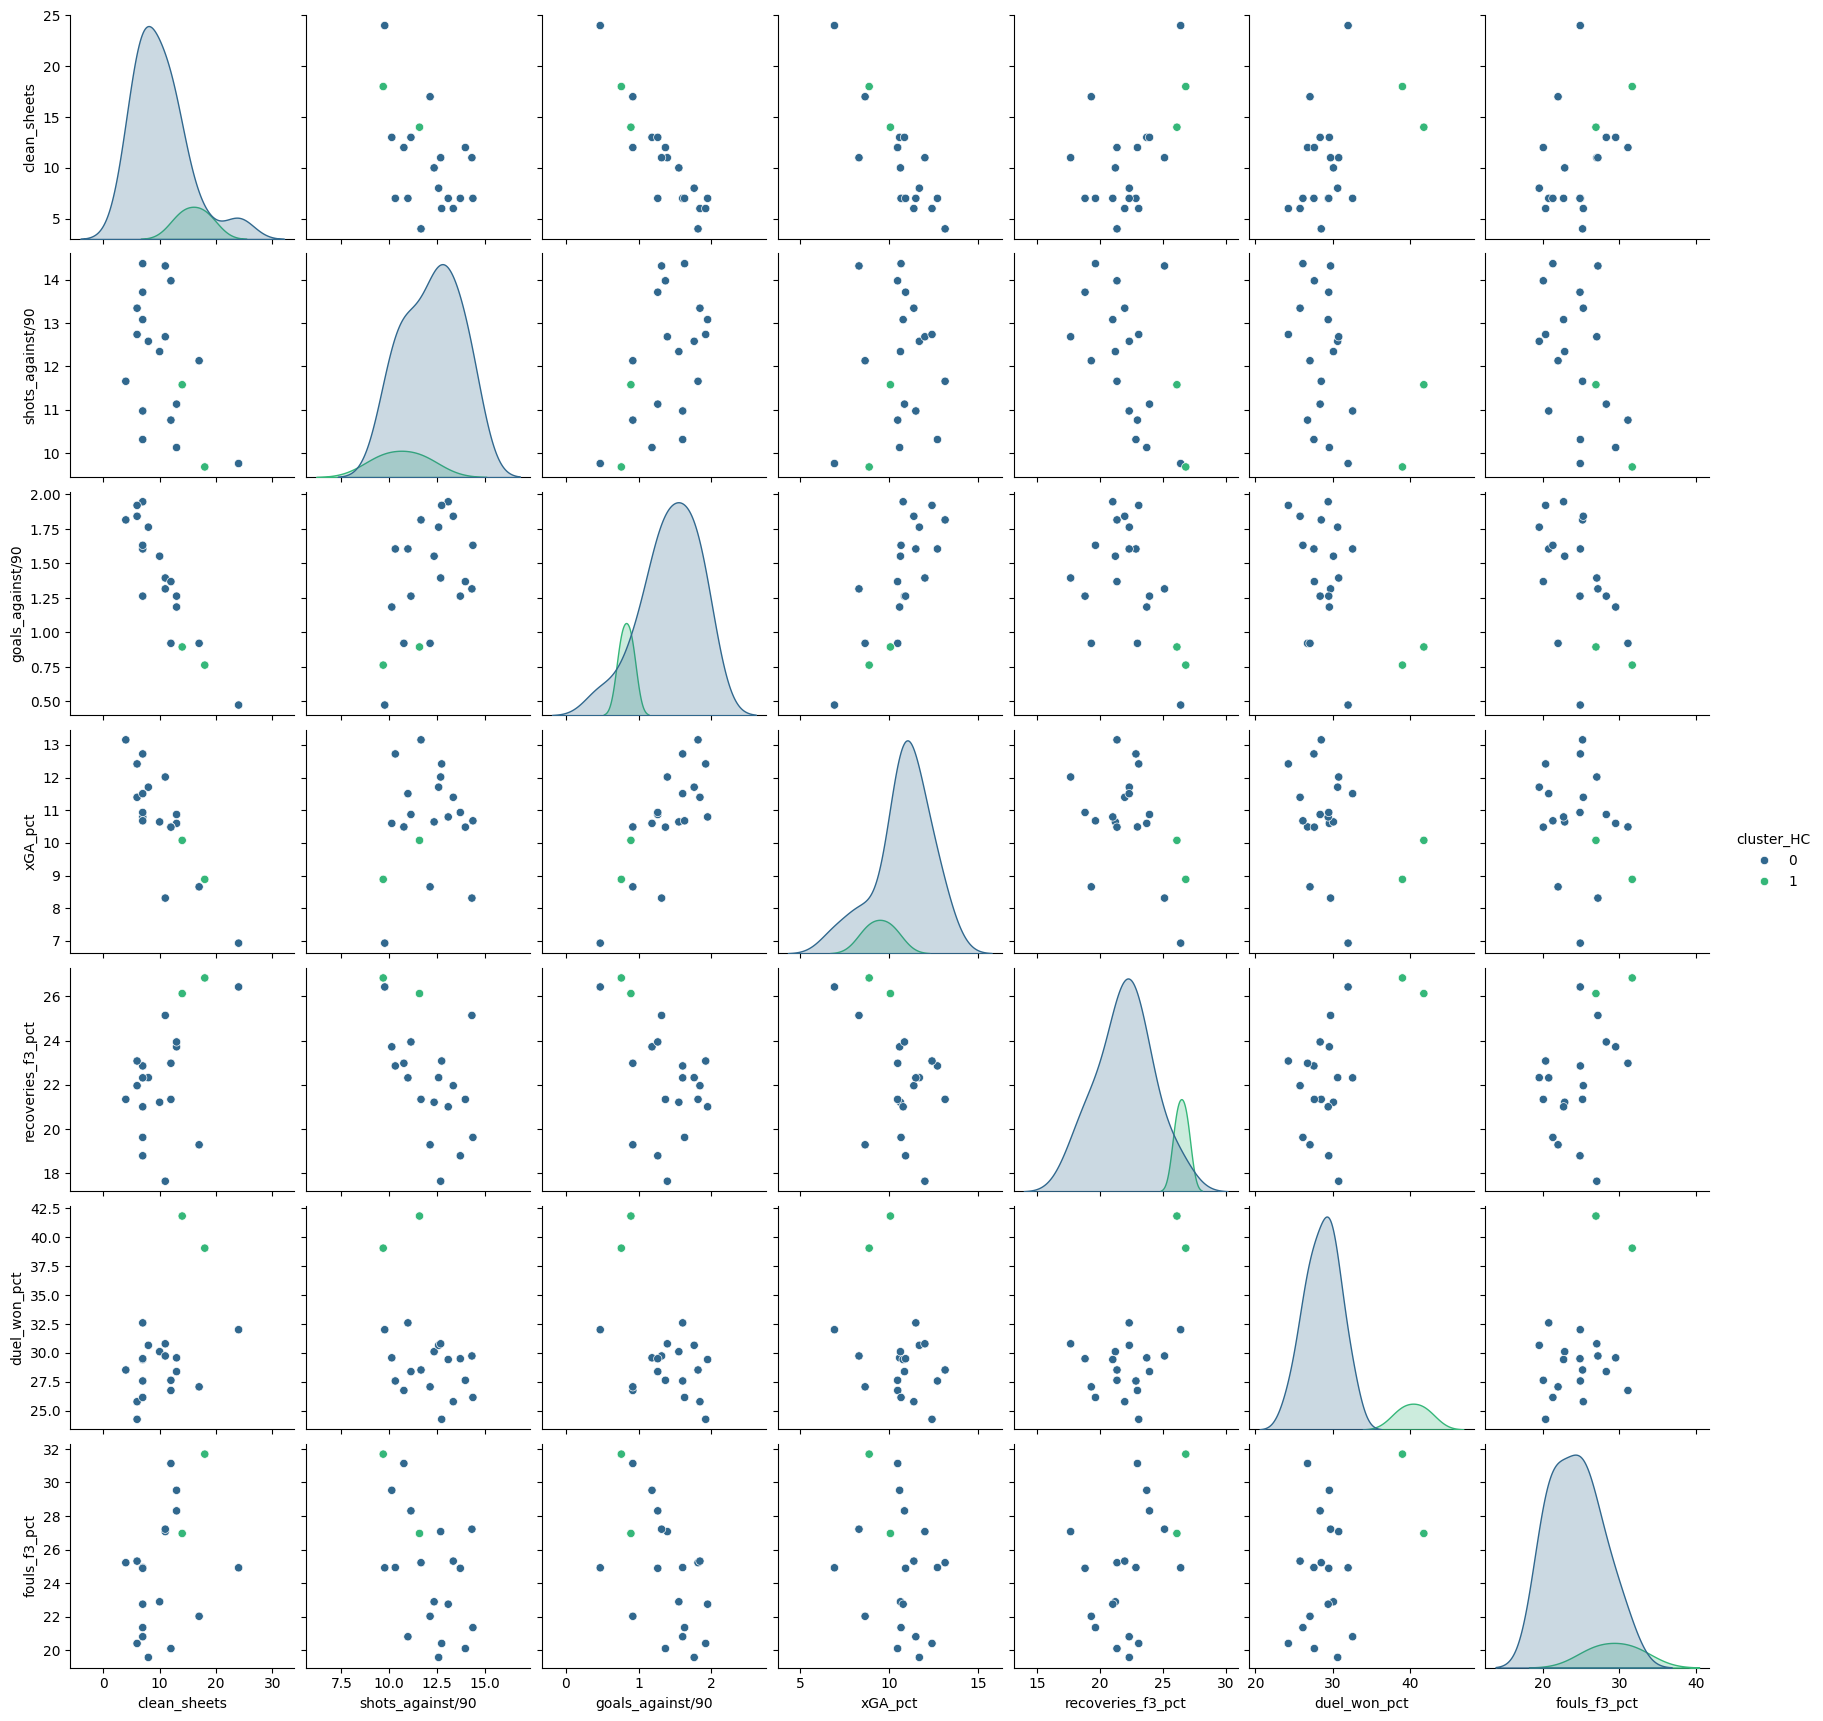

In [ ]:
selected_features_defense = ['clean_sheets', 'shots_against/90', 'goals_against/90', 'xGA_pct', 'recoveries_f3_pct', 'duel_won_pct', 'fouls_f3_pct', 'cluster_HC']
sns.pairplot(dfModel[selected_features_defense], hue='cluster_HC', palette='viridis')